# Example: Sample Portfolio Weights with the Dirichlet Distribution
Suppose we want to divide an initial investment among several stocks. We divide the budget among the stocks using nonnegative fractions (portfolio weights) that sum to one, so the full budget is invested. Many allocations satisfy these constraints. How can we explore them and compare the portfolios they produce?

The Dirichlet distribution gives us a way to draw valid portfolio weights and control whether the allocations spread across assets or concentrate in a few. Comparing their estimated growth and risk lets us judge the draws against a chosen objective.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Sample and interpret portfolio weights:** Generate nonnegative weights that sum to one using the Dirichlet distribution, explain the effect of its concentration parameters, and compare sample means and variances with the theoretical values.
>
> * **Compare portfolio growth and risk:** Compute the mean and standard deviation of the linear portfolio growth-rate proxy for sampled allocations and identify the lowest-variance draw.
>
> * **Follow buy-and-hold portfolios:** Convert initial weights into share counts, calculate wealth from historical prices, and explain why the weights change even when the share counts remain fixed.

In this example, we begin with three assets so we can visualize the sampled weights on a triangle. We then explore the growth and risk of five-asset allocations and compare selected buy-and-hold wealth paths over the final year of the training data.

Let's get started!

___


## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, loads the packages used here, and includes local helper code.

Let's set up our code environment:


In [1]:
# Load the course environment, distributions, plotting, and local helpers -
include(joinpath(@__DIR__, "Include.jl")); # resolve setup relative to this notebook

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
Our training dataset contains daily price records for stocks in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500), along with several exchange-traded funds and volatility products, from January 3, 2014 through December 31, 2024. Each record includes open, high, low, and close prices, as well as the volume-weighted average price.

We use each day's volume-weighted average price for both the growth-rate and wealth calculations. It averages transaction prices using the number of shares traded as weights and is stored in the `volume_weighted_average_price` column.

Let's load the data by calling [the MyTrainingMarketDataSet() function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet). We store the ticker-keyed dictionary in `original_dataset::Dict{String,DataFrame}`:


In [2]:
# Load the 2014–2024 price histories as a dictionary keyed by ticker -
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # extract the price tables from the bundle

Not all tickers in our dataset have the maximum number of trading days for various reasons, such as acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days.

First, let's use a firm known to have a complete record, `AAPL`, to compute the maximum number of trading days. We save that value in `maximum_number_trading_days::Int64`:

In [3]:
# Use AAPL's complete record to set the required history length -
maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # number of price observations

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # Initialize -
    dataset = Dict{String, DataFrame}(); # one retained price table per ticker

    # Keep full histories before selecting the example portfolios -
    # The retained histories in this dataset share trading dates.
    for (ticker, data) ∈ original_dataset 
        if (nrow(data) == maximum_number_trading_days) # retain tickers with complete histories
            dataset[ticker] = data;
        end
    end
    dataset; # return the filtered dictionary from the local let block
end;

Next, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable:

In [5]:
# Make the available ticker list reproducible despite dictionary iteration order -
list_of_tickers = keys(dataset) |> collect |> sort; # the examples use their explicit my_tickers orders

### Constants and Portfolios
Let's specify the constants we will use and the two small portfolios we will explore: three firms for the pictures (a three-asset simplex is a triangle we can draw) and five for the risk-growth cloud. Check that every ticker is in the cleaned dataset:

In [6]:
# Set the asset order and number of candidate allocations -
Δt = (1/252); # time step (1 trading day, in years)
my_tickers_3 = ["AAPL", "JNJ", "WMT"]; # three-asset portfolio for the simplex pictures
my_tickers_5 = ["AAPL", "JNJ", "WMT", "JPM", "NVDA"]; # five-asset portfolio for the risk-growth cloud
number_of_samples = 5000; # Dirichlet draws per experiment
# Check membership before forming matrices; the three-asset list is a subset of this list.
for t ∈ my_tickers_5
    @assert haskey(dataset, t) "ticker $(t) is not in the cleaned dataset"
end
(my_tickers_3 = my_tickers_3, my_tickers_5 = my_tickers_5, number_of_samples = number_of_samples)
Random.seed!(5660); # reproduce draws when cells are rerun in the same order

___

## Task 1: Draw Weights on the Three-Asset Simplex
In this task, we draw portfolio weights for three assets and examine how the Dirichlet concentration parameters change the resulting allocations.

For three assets, the portfolio weights are nonnegative and sum to one. Once we choose $w_1$ and $w_2$, the third weight is determined by:
$$
w_3 = 1-w_1-w_2.
$$
Thus, the constraints $w_1\geq 0$, $w_2\geq 0$, and $w_1+w_2\leq 1$ describe a triangle in the $(w_1,w_2)$ plane. The corners $(1,0)$, $(0,1)$, and $(0,0)$ place the entire budget in the first, second, and third assets, respectively. The point $(1/3,1/3)$ assigns one third of the budget to each asset. This triangle is the three-asset __simplex__.

The [Dirichlet distribution](https://juliastats.org/Distributions.jl/stable/multivariate/#Distributions.Dirichlet) draws weight vectors inside this triangle. Its concentration vector $\boldsymbol{\alpha}=(\alpha_1,\alpha_2,\alpha_3)$, with each $\alpha_i>0$, controls where the draws tend to fall. We compare four choices:

| Concentration vector | What we expect to see |
| --- | --- |
| $(0.5,0.5,0.5)$ | More allocations near the edges and corners. |
| $(1,1,1)$ | Constant density over the triangle. |
| $(5,5,5)$ | Allocations clustered near equal weights. |
| $(5,1,1)$ | More of the budget typically assigned to the first asset. |

Let's generate `number_of_samples` weight vectors for each choice using the [Distributions.jl package](https://juliastats.org/Distributions.jl/stable/). We store the results in `dirichlet_samples::Dict{String,Matrix{Float64}}`, with one matrix per concentration vector and one weight vector per column:


In [ ]:
dirichlet_samples = let
    
    # Initialize -
    # Compare concentration choices with the same number of sampled allocations -
    concentrations = Dict("α = (0.5, 0.5, 0.5)" => [0.5, 0.5, 0.5], "α = (1, 1, 1)" => [1.0, 1.0, 1.0],
        "α = (5, 5, 5)" => [5.0, 5.0, 5.0], "α = (5, 1, 1)" => [5.0, 1.0, 1.0]);
    
    samples = Dict{String, Matrix{Float64}}(); # label → matrix whose rows follow my_tickers_3
    
    
    for (label, α) ∈ concentrations
        d = Dirichlet(α); # positive concentrations define a distribution over budget fractions
        W = rand(d, number_of_samples); # 3 × number_of_samples, one weight vector per column
        @assert all(W .> 0) && all(isapprox.(sum(W, dims=1), 1.0; atol=1e-12)) # positive weights summing to one
        samples[label] = W; # keep all draws for both plotting and the moment check
    end
    samples
end;
keys(dirichlet_samples) # display the concentration cases available for comparison

KeySet for a Dict{String, Matrix{Float64}} with 4 entries. Keys:
  "α = (5, 1, 1)"
  "α = (1, 1, 1)"
  "α = (0.5, 0.5, 0.5)"
  "α = (5, 5, 5)"

Each sampled weight is positive, and the weights in each column sum to one. Thus, a draw can be close to an edge or corner while still assigning some of the budget to every asset.

Let's plot the first 1,500 draws from each sample so the points remain readable. The red point marks equal weights, and the third weight is $w_3=1-w_1-w_2$:

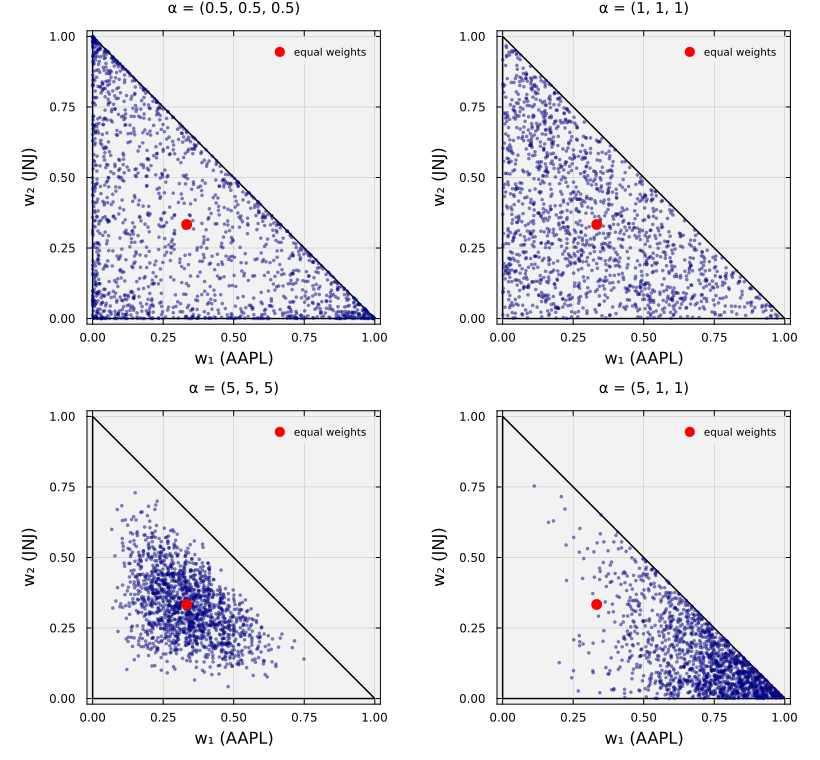

In [8]:
let
    # Fix panel order independently of the dictionary order -
    order = ["α = (0.5, 0.5, 0.5)", "α = (1, 1, 1)", "α = (5, 5, 5)", "α = (5, 1, 1)"];
    panels = []; # collect one plot object per concentration case
    for label ∈ order
        W = dirichlet_samples[label];
        # Draw the feasible triangle: the omitted third weight is 1-w₁-w₂.
        p = plot([0, 1, 0, 0], [0, 0, 1, 0]; color=:black, lw=1.5, label="", title=label, titlefontsize=10,
            xlabel="w₁ ($(my_tickers_3[1]))", ylabel="w₂ ($(my_tickers_3[2]))", xlims=(-0.02, 1.02), ylims=(-0.02, 1.02), aspect_ratio=:equal)
        # Show only 1,500 columns to limit overplotting; all samples remain stored.
        scatter!(p, W[1, 1:1500], W[2, 1:1500]; ms=2, msw=0, alpha=0.5, color=:navy, label="")
        scatter!(p, [1/3], [1/3]; ms=6, color=:red, msw=0, label="equal weights")
        push!(panels, p)
    end
    # Combine the four plots; ... passes each plot as a separate argument.
    plot(panels...; layout=(2,2), size=(820, 760), legend=:topright, legendfontsize=7,
        bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent)
end

__What do we see?__ The panels show how the concentration vector changes the allocations. Small symmetric concentrations favor portfolios with most of the budget in one or two assets, while large symmetric concentrations keep the weights closer to one third. With $\boldsymbol{\alpha}=(5,1,1)$, the cloud shifts toward larger values of $w_1$.

### Check: Sample Mean and Variance
We have analytical expressions for the mean and variance of the Dirichlet distribution. Let's check our observations against these expressions. Treat each weight $w_i$ as a random variable, and let $\alpha_0=\alpha_1+\alpha_2+\alpha_3$ be the sum of the concentration parameters. 

The mean and variance of each weight are given by:
$$
\mathbb{E}[w_i] = \frac{\alpha_i}{\alpha_0},\qquad
\operatorname{Var}(w_i) = \frac{\alpha_i(\alpha_0-\alpha_i)}{\alpha_0^2(\alpha_0+1)}.
$$
For $\boldsymbol{\alpha}=(5,1,1)$, we have $\alpha_0=7$, so the expected weights are $(5/7,1/7,1/7)$. Let's compare the sample means and variances with these formulas. We store the comparison in `moment_table::DataFrame`, with one row per asset:


In [9]:
moment_table = let
    α = [5.0, 1.0, 1.0]; # concentration parameters for the moment check
    α₀ = sum(α); # total concentration
    W = dirichlet_samples["α = (5, 1, 1)"]; # reuse the same draws rather than simulate a second sample
    df = DataFrame(asset = String[], sample_mean = Float64[], formula_mean = Float64[], sample_var = Float64[], formula_var = Float64[]);
    # Row i contains asset i across all draws; compare empirical and theoretical moments.
    for i ∈ 1:3
        push!(df, (my_tickers_3[i], mean(W[i,:]), α[i]/α₀, var(W[i,:]), α[i]*(α₀ - α[i])/(α₀^2*(α₀ + 1))));
    end
    df # one row per asset, preserving my_tickers_3 order
end
# Round the displayed moments only; keep full precision in moment_table -
pretty_table(moment_table; formatters = [fmt__printf("%.4f", [2,3,4,5])])

┌────────┬─────────────┬──────────────┬────────────┬─────────────┐
│  asset │ sample_mean │ formula_mean │ sample_var │ formula_var │
│ String │     Float64 │      Float64 │    Float64 │     Float64 │
├────────┼─────────────┼──────────────┼────────────┼─────────────┤
│   AAPL │      0.7127 │       0.7143 │     0.0255 │      0.0255 │
│    JNJ │      0.1436 │       0.1429 │     0.0156 │      0.0153 │
│    WMT │      0.1437 │       0.1429 │     0.0150 │      0.0153 │
└────────┴─────────────┴──────────────┴────────────┴─────────────┘


The sample means and variances are close to the theoretical values. Small differences are expected because we use a finite number of random draws; changing the sample size or random seed will change those differences.

Next, we will use the sampled allocations to compare portfolio growth and risk.

___

## Task 2: Explore Portfolio Growth and Risk Across the Simplex
In this task, we compare portfolios with different allocations across five stocks. We estimate each portfolio’s mean growth rate and risk, compare it with equal-weight and single-stock portfolios, and identify the sampled portfolio with the lowest growth-rate variance.

A weight vector tells us how to divide the budget among the five assets in the portfolio. To compare allocations, we also need to describe the growth rates of the assets they contain. For a chosen weight vector $\mathbf{w}$, we use the lecture's linear approximation to the portfolio growth rate over one period:
$$
g_p = \mathbf{w}^{\top}\mathbf{g} = \sum_{i=1}^{5}w_i g_i.
$$
Here $g_i$ is the growth rate of asset $i$ over that period, and $\mathbf{g}$ collects the five asset growth rates. This expression weights each growth rate by its fraction of the budget. 

Let's first estimate the asset growth-rate mean vector $\mathbf{g}^{\prime}$ and covariance matrix $\hat{\mathbf{\Sigma}}_g$ from the training data. [The log_growth_matrix(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) returns an $N\times 5$ matrix, with one row per daily growth observation and columns in the order of `my_tickers_5`. We will store the column means and sample covariance in `g_mean_5::Vector{Float64}` and `Σ̂_5::Matrix{Float64}`.

We'll also report each asset's __volatility__, the $\sigma_i$ parameter in its geometric Brownian motion model estimated from the growth-rate standard deviation:
$$
\hat{\sigma}_i = \sqrt{\Delta t}\,\sqrt{\hat{\Sigma}_{g,ii}},\qquad \Delta t=1/252\ \text{years}.
$$
The `growth_std` column reports $\sqrt{\hat{\Sigma}_{g,ii}}$ in inverse years, while the `volatility` column reports $\hat{\sigma}_i$ in inverse square-root years. Let's compute the estimates and display the results:

In [ ]:
g_mean_5, Σ̂_5 = let
    # This call uses the helper default Δt=1/252; keep it consistent with the volatility scaling.
    G = log_growth_matrix(dataset, my_tickers_5); # N daily intervals × 5 firms, in year⁻¹
    g_mean = mean(G, dims=1) |> vec; # average each column, then return a vector in ticker order
    Σ = cov(G, dims=1); # sample covariance of columns, using N-1; units year⁻²
    # Allow tiny negative eigenvalues from roundoff when checking nonnegative variance.
    @assert isapprox(Σ, Σ'; atol=1e-10) && all(eigvals(Symmetric(Σ)) .>= -1e-10) # symmetric, positive semidefinite
    (g_mean, Σ)
end;

# Compare growth-rate standard deviation with volatility = sqrt(Δt) × growth std -
pretty_table(DataFrame(ticker = my_tickers_5, mean_growth = g_mean_5, growth_std = sqrt.(diag(Σ̂_5)), volatility = sqrt.(Δt .* diag(Σ̂_5)));
    formatters = [fmt__printf("%.3f", [2,3,4])])

┌────────┬─────────────┬────────────┬────────────┐
│ ticker │ mean_growth │ growth_std │ volatility │
│ String │     Float64 │    Float64 │    Float64 │
├────────┼─────────────┼────────────┼────────────┤
│   AAPL │       0.233 │      3.723 │      0.235 │
│    JNJ │       0.041 │      2.441 │      0.154 │
│    WMT │       0.113 │      2.862 │      0.180 │
│    JPM │       0.128 │      3.719 │      0.234 │
│   NVDA │       0.532 │      6.169 │      0.389 │
└────────┴─────────────┴────────────┴────────────┘


### Compute Growth and Risk for Each Allocation
For a fixed weight vector $\mathbf{w}$, the sample mean and standard deviation of the linear growth-rate approximation are given by:
$$
g^{\prime}_p(\mathbf{w}) = \mathbf{w}^{\top}\mathbf{g}^{\prime},\qquad
\sigma_{g,p}(\mathbf{w}) = \sqrt{\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_g\mathbf{w}}.
$$

We will use $g^{\prime}_p(\mathbf{w})$ as the __reward__ and $\sigma_{g,p}$ as the __risk__ coordinates in our plot. Let's draw `number_of_samples` weight (random) vectors with $\alpha_i=1$ for all five assets, giving constant density over the simplex. For each draw, we calculate $g^{\prime}_p$ and $\sigma_{g,p}$ and store them, together with the weights, in `cloud_df::DataFrame`, one row per allocation:

In [ ]:
cloud_df = let

    # initialize -
    d = Dirichlet(ones(length(my_tickers_5))); # α_i=1 gives constant density over feasible weights
    W = rand(d, number_of_samples); # 5 × number_of_samples, one allocation per column
    df = DataFrame(g_p = Float64[], σ_gp = Float64[], w = Vector{Float64}[]);
    
    # compute loop -
    for k ∈ 1:number_of_samples
        w = W[:,k]; # weights in the same order as g_mean_5 and Σ̂_5
        push!(df, (dot(w, g_mean_5), sqrt(dot(w, Σ̂_5*w)), w)); # Compute wᵀg′ and sqrt(wᵀΣ̂w), both in year⁻¹; also retain the allocation.
    end
    df # rows are candidate portfolios, not observation dates
end;

Let's display the first three allocations as a table using [the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/lib/library/#PrettyTables.pretty_table), with a separate weight column for each asset:


In [12]:
let
    rows = first(cloud_df, 3); # show a small sample without changing cloud_df
    table = select(rows, :g_p, :σ_gp); # start with the two performance coordinates
    for (i, ticker) ∈ enumerate(my_tickers_5)
        table[!, ticker] = [w[i] for w ∈ rows.w]; # unpack each stored weight vector into a labeled numeric column
    end
    pretty_table(table; formatters = [fmt__printf("%.4f", 1:ncol(table))]);
end

┌─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│     g_p │    σ_gp │    AAPL │     JNJ │     WMT │     JPM │    NVDA │
│ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │
├─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│  0.2202 │  2.7890 │  0.3518 │  0.1142 │  0.0911 │  0.2782 │  0.1647 │
│  0.3622 │  4.1740 │  0.0310 │  0.2710 │  0.0006 │  0.0679 │  0.6294 │
│  0.3013 │  3.3356 │  0.3280 │  0.1026 │  0.1912 │  0.0055 │  0.3728 │
└─────────┴─────────┴─────────┴─────────┴─────────┴─────────┴─────────┘


### Compare the Sampled Portfolios
Let's plot the sampled allocations with growth-rate standard deviation on the horizontal axis and mean growth rate on the vertical axis. We also mark the five single-asset portfolios, the equal-weight portfolio, and the lowest-variance draw:


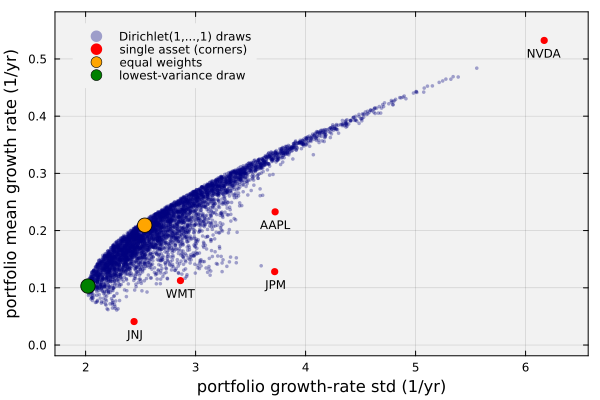

In [13]:
let
    # Display sampled portfolios in growth-standard-deviation coordinates -
    scatter(cloud_df.σ_gp, cloud_df.g_p; ms=2, msw=0, alpha=0.35, color=:navy, label="Dirichlet(1,...,1) draws",
        xlabel="portfolio growth-rate std (1/yr)", ylabel="portfolio mean growth rate (1/yr)")
    # Add reference allocations; the lowest-variance draw is not an optimization solution.
    σ_single = sqrt.(diag(Σ̂_5)); # single-asset portfolios
    scatter!(σ_single, g_mean_5; ms=4, color=:red, msw=0, label="single asset (corners)")
    for i ∈ eachindex(my_tickers_5)
        annotate!(σ_single[i], g_mean_5[i] - 0.012, text(my_tickers_5[i], 8, :top))
    end
    plot!(xlims=(minimum(cloud_df.σ_gp) - 0.3, maximum(σ_single) + 0.4), ylims=(minimum(cloud_df.g_p) - 0.08, maximum(g_mean_5) + 0.05))
    w_eq = fill(1/length(my_tickers_5), length(my_tickers_5)); # equal fractions sum to one
    scatter!([sqrt(dot(w_eq, Σ̂_5*w_eq))], [dot(w_eq, g_mean_5)]; ms=8, color=:orange, msw=1, label="equal weights")
    kmin = argmin(cloud_df.σ_gp); # smallest sampled standard deviation also minimizes sampled variance
    scatter!([cloud_df.σ_gp[kmin]], [cloud_df.g_p[kmin]]; ms=8, color=:green, msw=1, label="lowest-variance draw")
    plot!(bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent, legend=:topleft)
end

__So what do we see?__ The cloud shows the combinations of estimated growth and risk reached by our sampled weights. Its curved left edge shows the lowest risks reached at different growth levels within the sample.

__Why can combining assets reduce risk?__ For nonnegative weights that sum to one, the portfolio standard deviation is no greater than the weighted average of the individual standard deviations. Thus, when the assets receiving weight do not all move together perfectly, _diversification_ lowers risk below that weighted average. Compare the equal-weight and lowest-variance points with the single-asset points to see the reduction achieved for these data.

Let's print the lowest-variance draw and compare its risk with that of the least risky single asset:

In [14]:
let
    kmin = argmin(cloud_df.σ_gp); # select among the stored draws only
    w_min = cloud_df.w[kmin]; # recover that row's five investment fractions
    i_single = argmin(sqrt.(diag(Σ̂_5))); # least risky single asset in the same five-firm universe
    # Report the chosen allocation and compare it with the single-asset baseline -
    println("Lowest-variance draw: growth-rate std = $(round(cloud_df.σ_gp[kmin], digits=3)) 1/yr, mean growth rate = $(round(cloud_df.g_p[kmin], digits=3)) 1/yr")
    pretty_table(DataFrame(ticker = my_tickers_5, weight = w_min); formatters = [fmt__printf("%.3f", [2])])
    println("Least risky single asset: $(my_tickers_5[i_single]) with growth-rate std = $(round(sqrt(Σ̂_5[i_single,i_single]), digits=3)) 1/yr")
end

Lowest-variance draw: growth-rate std = 2.021 1/yr, mean growth rate = 0.103 1/yr
┌────────┬─────────┐
│ ticker │  weight │
│ String │ Float64 │
├────────┼─────────┤
│   AAPL │   0.118 │
│    JNJ │   0.441 │
│    WMT │   0.338 │
│    JPM │   0.088 │
│   NVDA │   0.016 │
└────────┴─────────┘
Least risky single asset: JNJ with growth-rate std = 2.441 1/yr


The selected allocation has the smallest estimated variance among our `number_of_samples` draws. However, we have not established the smallest variance attainable over all nonnegative weights that sum to one (this is just the lowest variance among our random draws).

__How do I find the optimal allocation?__ Finding the optimal allocation is the solution to the _global minimum-variance problem_ under these weight constraints. We'll consider this quadratic optimization problem in the next lecture!

___

## Task 3: Buy-and-Hold Wealth and Weight Drift
In this task, we compare the equal-weight portfolio, the lowest-variance draw from Task 2, and three additional portfolios sampled from a uniform Dirichlet distribution. We convert their initial weights into share counts, compute buy-and-hold wealth over the final 252 trading days of the training data, and examine how the weights change (drift) even when the share counts remain fixed! This is an __in-sample illustration__: the price window is part of the training data used to estimate the covariance matrix and select the lowest-variance draw.

Suppose our initial budget is $W_0>0$ dollars and our chosen weights are $\mathbf{w}$. If asset $i$ has an initial share price $S_i(0)$, say the open price in dollars per share, the number of shares we purchase when establishing the portfolio is given by:
$$
n_i = \frac{w_i W_0}{S_i(0)},\qquad i=1,\ldots,5.
$$
We allow fractional shares and do not add transaction costs or separate dividend payments. Holding the share counts fixed, the value of our holding in asset $i$ at time $t$ is $n_i S_i(t)$. As derived in the lecture, total wealth is the sum of these holding values, and wealth relative to the initial budget is a weighted average of the asset price ratios using the __initial__ portfolio weights:
$$
\frac{W_t}{W_0} = \sum_{i=1}^{5}w_i\frac{S_i(t)}{S_i(0)}.
$$

Here $t=0$ denotes the first price observation in the selected window. We use the recorded volume-weighted average prices and store wealth relative to the initial budget, $W_t/W_0$, in `wealth_df::DataFrame`, with one column per portfolio. The `holdings` dictionary stores the fixed share counts. Let's compute these quantities:

In [19]:
wealth_df, holdings = let
    
    # initialize -
    W₀ = 10_000.0; # initial budget (USD)
    n_days = 252; # price observations from training data: 251 successive growth intervals
    # Place each firm's aligned price history in a column; the first row is the purchase date.
    prices = hcat([dataset[t][end-n_days+1:end, :volume_weighted_average_price] for t ∈ my_tickers_5]...); # n_days × 5
    portfolios = Dict{String, Vector{Float64}}(); # label → initial weights in my_tickers_5 order
    portfolios["equal weights"] = fill(1/5, 5);
    portfolios["lowest-variance draw"] = cloud_df.w[argmin(cloud_df.σ_gp)];
    d = Dirichlet(ones(5)); # uniform distribution over five-asset weights
    rng_draws = rand(d, 3); # 5 × 3 matrix: each column is another initial allocation
    
    for k ∈ 1:3
        portfolios["Dirichlet draw $(k)"] = rng_draws[:,k];
    end
    df = DataFrame(day = 1:n_days); # day 1 corresponds to t=0, before any price change
    holdings = Dict{String, Vector{Float64}}();
    
    # Buy once and retain the share counts; subsequent price changes alter wealth and weights.
    for (label, w) ∈ portfolios
        n = w .* W₀ ./ prices[1,:]; # invested dollars / dollars per share; fractional shares allowed
        holdings[label] = n;
        df[!, label] = prices*n ./ W₀; # matrix-vector product sums holding values on each date; normalize
    end
    (df, holdings)
end;

Let's plot the paths to compare how the initial allocations affect wealth over the selected window:

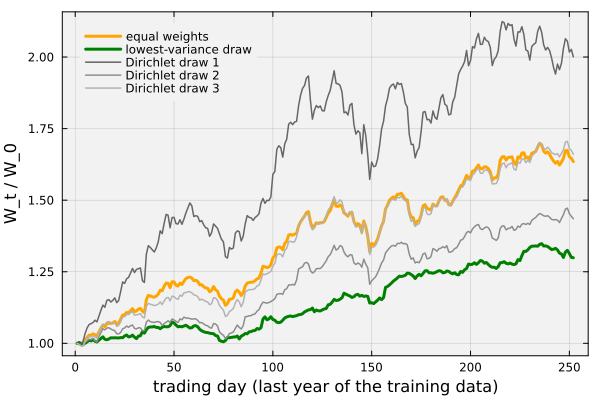

In [17]:
let
    # Choose a consistent plotting order for the two reference portfolios and three draws -
    labels = ["equal weights", "lowest-variance draw", "Dirichlet draw 1", "Dirichlet draw 2", "Dirichlet draw 3"];
    colors = [:orange, :green, :gray40, :gray55, :gray70];
    p = plot(xlabel="trading day (last year of the training data)", ylabel="W_t / W_0", legend=:topleft)
    # Pair each label with its color; thicker lines emphasize the reference allocations.
    for (label, c) ∈ zip(labels, colors)
        plot!(p, wealth_df.day, wealth_df[!, label]; lw=(startswith(label,"Dirichlet") ? 1.5 : 3), color=c, label=label)
    end
    plot!(p, bg="gray95", background_color_outside="white", framestyle=:box, fg_legend=:transparent)
end

__What do we see?__ Every path starts at one, the initial budget. A value above one means the portfolio is worth more than we paid for it, and a value below one means it's worth less. The paths spread apart because each portfolio holds different amounts of each stock.

### How Do the Weights Change?
The share counts stay fixed, but each asset's value changes with its price. To measure the resulting weight drift, we compute the fraction of total wealth held in each asset at the final observation, denoted by time $T$:
$$
w_i(T) = \frac{n_i S_i(T)}{W_T}.
$$
Let's compare these final weights with the initial weights of the equal-weight portfolio. We store the comparison in `drift_table::DataFrame` and display it using [the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/lib/library/#PrettyTables.pretty_table):


In [18]:
drift_table = let
    n_days = 252; # matches the wealth illustration; final prices are taken from the last stored row
    prices_end = [dataset[t][end, :volume_weighted_average_price] for t ∈ my_tickers_5];
    n = holdings["equal weights"]; # reuse the original share counts; do not rebalance
    W_T = dot(n, prices_end); # sum final holding values to obtain total wealth in dollars
    # Each final weight is its holding value divided by total wealth; weights again sum to one.
    DataFrame(ticker = my_tickers_5, initial_weight = fill(0.2, 5), final_weight = n .* prices_end ./ W_T)
end
pretty_table(drift_table; formatters = [fmt__printf("%.3f", [2,3])])

┌────────┬────────────────┬──────────────┐
│ ticker │ initial_weight │ final_weight │
│ String │        Float64 │      Float64 │
├────────┼────────────────┼──────────────┤
│   AAPL │          0.200 │        0.165 │
│    JNJ │          0.200 │        0.110 │
│    WMT │          0.200 │        0.209 │
│    JPM │          0.200 │        0.171 │
│   NVDA │          0.200 │        0.345 │
└────────┴────────────────┴──────────────┘


__What do we see?__ Compare each final weight with its initial value of $0.2$. An asset's weight increases when its percentage price change exceeds the portfolio's percentage change in wealth, and decreases when it falls below it. Thus, even an asset whose price rises can finish with a smaller weight if the other holdings grow faster.

The table shows that portfolio weights change over time. Restoring the initial weights would require selling shares of assets above their target weights and buying shares of those below their targets. This is __rebalancing__, which changes the share counts and can introduce trading costs.

___

## Summary
In this example, we sampled portfolio weights with the Dirichlet distribution, compared their estimated growth and risk, and followed selected allocations through historical prices.

> __Key Takeaways:__
>
> * **Sampling portfolio weights:** We used the Dirichlet distribution to generate nonnegative weights that sum to one. Small symmetric concentrations favored allocations near the edges and corners, large symmetric concentrations clustered near equal weights, and unequal concentrations shifted the expected allocation toward selected assets. Comparing sample means and variances with the theoretical values checked the behavior of our draws.
>
> * **Comparing growth and risk:** We used the linear portfolio growth-rate approximation and the sample covariance matrix to compare allocations and examine how combining assets can reduce risk. The selected draw had the smallest estimated variance among the sampled portfolios. Finding the minimum over all nonnegative weights that sum to one requires solving an optimization problem.
>
> * **Following wealth and weight drift:** We converted initial weights into fixed share counts and computed normalized wealth as a weighted sum of asset price ratios. Using a window from the training data, we showed how relative price changes alter the portfolio weights even when the share counts stay fixed. Restoring the initial weights requires rebalancing.

Sampling lets us explore candidate allocations. In upcoming lectures, we solve for weights that minimize estimated risk, with or without a required mean growth rate.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___